In [473]:
import pandas as pd
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
import torch
from sklearn.preprocessing import StandardScaler
from torch import nn

In [474]:
df = pd.read_csv("global_supply_chain_risk_2026.csv")

# 1. Target Encoding (Note: using 'Occurred' with double 'r')
target_col = "Disruption_Occurred"

originEncoder = TargetEncoder(cols=["Origin_Port"], smoothing=10.0)
df["Origin_Port_encoded"] = originEncoder.fit_transform(
    df["Origin_Port"], df[target_col]
)

destinationEncoder = TargetEncoder(cols=["Destination_Port"], smoothing=10.0)
df["Destination_Port_encoded"] = destinationEncoder.fit_transform(
    df["Destination_Port"], df[target_col]
)

df.drop(columns=["Origin_Port", "Destination_Port"], inplace=True)

# 2. One-Hot Encoding (Added dtype=int for model compatibility)
df = pd.get_dummies(
    df, columns=["Transport_Mode", "Product_Category", "Weather_Condition"], dtype=int
)

# 3. Date Features
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# 4. Final Cleanup
df.drop(columns=["Date", "Shipment_ID"], inplace=True)
df.dropna(inplace=True)

# 5. Global conversion to float (required for many ML models)
df = df.astype(float)


print(f"Preprocessing complete. New shape: {df.shape}")

Preprocessing complete. New shape: (5000, 26)


In [475]:
df.head()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Origin_Port_encoded,Destination_Port_encoded,Transport_Mode_Air,...,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Clear,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm,Year,Month,Day
0,5930.83,197.42,2.43,5.0,0.865,41.39,1.0,0.622705,0.597765,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2025.0,10.0,16.0
1,14285.36,237.24,2.30,7.5,0.592,40.92,1.0,0.622705,0.618538,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2024.0,4.0,24.0
2,11113.91,427.42,1.78,5.6,0.673,11.54,0.0,0.602167,0.597765,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2024.0,1.0,26.0
3,9180.55,170.66,3.20,0.8,0.832,53.13,1.0,0.602699,0.610075,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2024.0,10.0,8.0
4,2762.27,434.96,2.77,1.9,0.741,0.50,1.0,0.602699,0.632576,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2024.0,9.0,7.0


In [476]:
X = df.drop(columns=["Disruption_Occurred"])
y = df["Disruption_Occurred"]

In [477]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()

y_train = torch.from_numpy(y_train.to_numpy()).float().unsqueeze(1)
y_test = torch.from_numpy(y_test.to_numpy()).float().unsqueeze(1)

In [478]:
input_size = X_train.shape[1]


class Supply_Chain_Risk(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, X):
        return self.model(X)

In [479]:
torch.manual_seed(42)
model31 = Supply_Chain_Risk(input_size=input_size)

In [480]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model31.parameters(), lr=0.001)

In [481]:
epochs = 10
for epoch in range(epochs):
    model31.train()
    X_logits = model31(X_train)
    loss = loss_fn(X_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(loss)

tensor(0.7023, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6961, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6899, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6837, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6776, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6718, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6661, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6603, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6546, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6488, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [482]:
def AccFunc(preds, y_true):
    return (preds == y_true).float().mean() * 100

In [483]:
epochs = 200
for epoch in range(epochs):
    model31.train()
    X_logits = model31(X_train)
    X_preds = torch.round(torch.sigmoid(X_logits))
    loss = loss_fn(X_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model31.eval()
    with torch.inference_mode():
        test_logits = model31(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_preds = torch.round(torch.sigmoid(test_logits))
        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, Train Loss: {loss}, Test Loss: {test_loss}")

Epoch: 0, Train Loss: 0.6428954005241394, Test Loss: 0.6328098773956299
Epoch: 10, Train Loss: 0.5843352675437927, Test Loss: 0.5696278214454651
Epoch: 20, Train Loss: 0.5181701183319092, Test Loss: 0.5104764699935913
Epoch: 30, Train Loss: 0.4798962473869324, Test Loss: 0.4812544286251068
Epoch: 40, Train Loss: 0.46421194076538086, Test Loss: 0.4800369441509247
Epoch: 50, Train Loss: 0.4518129527568817, Test Loss: 0.4789232909679413
Epoch: 60, Train Loss: 0.4407136142253876, Test Loss: 0.4813396632671356
Epoch: 70, Train Loss: 0.429447740316391, Test Loss: 0.48739704489707947
Epoch: 80, Train Loss: 0.416341632604599, Test Loss: 0.49528130888938904
Epoch: 90, Train Loss: 0.3999245762825012, Test Loss: 0.504309892654419
Epoch: 100, Train Loss: 0.37853577733039856, Test Loss: 0.5154006481170654
Epoch: 110, Train Loss: 0.35113558173179626, Test Loss: 0.5332361459732056
Epoch: 120, Train Loss: 0.316501647233963, Test Loss: 0.5612114667892456
Epoch: 130, Train Loss: 0.280456006526947, Test 

In [484]:
print(f"Accuracy Function: {AccFunc(test_preds, y_test)}")

Accuracy Function: 68.5999984741211


In [485]:
print(df["Disruption_Occurred"].value_counts(normalize=True))

Disruption_Occurred
1.0    0.6126
0.0    0.3874
Name: proportion, dtype: float64


0:	learn: 0.7389072	test: 0.7388716	best: 0.7388716 (0)	total: 59.7ms	remaining: 59.6s
50:	learn: 0.7511652	test: 0.7383975	best: 0.7400306 (41)	total: 2.81s	remaining: 52.4s
100:	learn: 0.7841080	test: 0.7473792	best: 0.7532266 (86)	total: 5.66s	remaining: 50.4s
150:	learn: 0.7979987	test: 0.7490913	best: 0.7532266 (86)	total: 8.31s	remaining: 46.7s
200:	learn: 0.8124161	test: 0.7483538	best: 0.7532266 (86)	total: 11.2s	remaining: 44.6s
250:	learn: 0.8253851	test: 0.7440078	best: 0.7532266 (86)	total: 14.1s	remaining: 42.1s
300:	learn: 0.8409217	test: 0.7479587	best: 0.7532266 (86)	total: 17.5s	remaining: 40.6s
350:	learn: 0.8621198	test: 0.7423221	best: 0.7532266 (86)	total: 21s	remaining: 38.9s
400:	learn: 0.8762278	test: 0.7396091	best: 0.7532266 (86)	total: 24.5s	remaining: 36.6s
450:	learn: 0.8897433	test: 0.7378444	best: 0.7532266 (86)	total: 28s	remaining: 34.1s
500:	learn: 0.9060303	test: 0.7400306	best: 0.7532266 (86)	total: 31.5s	remaining: 31.4s
550:	learn: 0.9223173	test: 

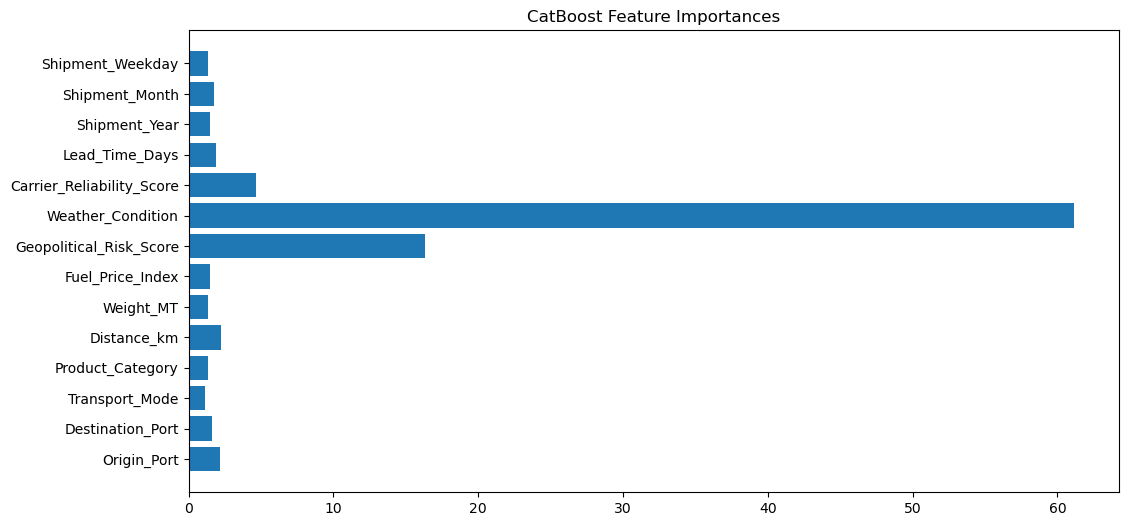

In [487]:
# %% Full improved CatBoost pipeline with class balancing & date features

import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

# 1️⃣ Load dataset
df = pd.read_csv("global_supply_chain_risk_2026.csv")

# 2️⃣ Extract date features
df["Date"] = pd.to_datetime(df["Date"])
df["Shipment_Year"] = df["Date"].dt.year
df["Shipment_Month"] = df["Date"].dt.month
df["Shipment_Weekday"] = df["Date"].dt.weekday

# 3️⃣ Drop unused columns
X = df.drop(columns=["Disruption_Occurred", "Shipment_ID", "Date"])
y = df["Disruption_Occurred"]

# 4️⃣ Identify categorical columns
cat_cols = [
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Weather_Condition",
]

# 5️⃣ Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6️⃣ Handle class imbalance
# Compute class weights
class_counts = y_train.value_counts()
weight_0 = class_counts[1] / class_counts[0]  # weight for class 0
weight_1 = 1.0  # keep majority class weight = 1
weights = [weight_0, weight_1]

# 7️⃣ Create CatBoost model with tuned hyperparameters
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    eval_metric="Accuracy",
    verbose=50,
    random_seed=42,
    class_weights=weights,
    use_best_model=True,
)

# 8️⃣ Train model
model.fit(X_train, y_train, cat_features=cat_cols, eval_set=(X_test, y_test))

# 9️⃣ Make predictions
preds = model.predict(X_test)

# 1️⃣0️⃣ Accuracy
accuracy = (preds == y_test).mean() * 100
print(f"CatBoost Accuracy: {accuracy:.2f}%")

# 1️⃣1️⃣ Feature importance plot
feature_importances = model.get_feature_importance()
features = X_train.columns

plt.figure(figsize=(12, 6))
plt.barh(features, feature_importances)
plt.title("CatBoost Feature Importances")
plt.show()